In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

sns.set(style="whitegrid")

In [7]:
np.random.seed(42)
dates = pd.date_range(start="2021-01-01", periods=730, freq="D")
trend = np.linspace(100, 300, 730)
seasonality = 20 * np.sin(np.linspace(0, 20*np.pi, 730))
noise = np.random.normal(0, 10, 730)

df = pd.DataFrame({
    "Date": dates,
    "Sales": trend + seasonality + noise
})
df.head()

,Date,Sales
0,2021-01-01,104.967142
1,2021-01-02,100.613354
2,2021-01-03,110.456098
3,2021-01-04,121.167259
4,2021-01-05,105.515208


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    730 non-null    datetime64[ns]
 1   Sales   730 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 11.5 KB
None
Date     0
Sales    0
dtype: int64


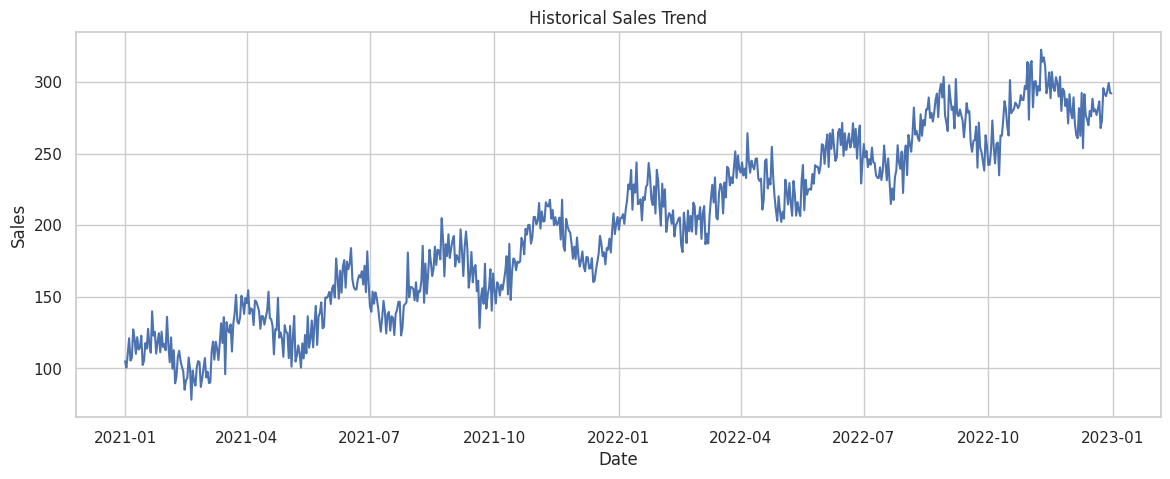

In [8]:
print(df.info())
print(df.isnull().sum())

df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)
df = df.dropna()  # or df.fillna(method="ffill") depending on your data

plt.figure(figsize=(14, 5))
plt.plot(df["Date"], df["Sales"])
plt.title("Historical Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

In [9]:
df["Day"] = df["Date"].dt.day
df["Month"] = df["Date"].dt.month
df["Year"] = df["Date"].dt.year
df["DayOfWeek"] = df["Date"].dt.dayofweek

features = ["Day", "Month", "Year", "DayOfWeek"]  # add real features (price, promo, etc.) if you have them
X = df[features]
y = df["Sales"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [10]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)

rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

In [11]:
def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{name} -> MAE: {mae:.2f} | RMSE: {rmse:.2f} | R²: {r2:.3f}")

evaluate(y_test, lr_preds, "Linear Regression")
evaluate(y_test, rf_preds, "Random Forest")

Linear Regression -> MAE: 14.96 | RMSE: 18.13 | R²: -0.074
Random Forest -> MAE: 29.65 | RMSE: 33.72 | R²: -2.717


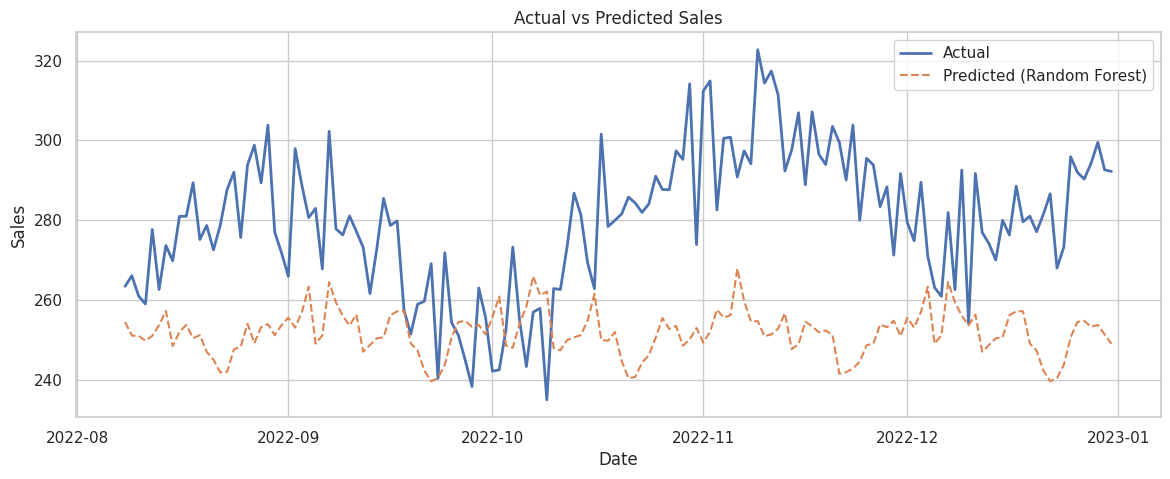

In [12]:
plt.figure(figsize=(14, 5))
plt.plot(df["Date"].iloc[-len(y_test):], y_test.values, label="Actual", linewidth=2)
plt.plot(df["Date"].iloc[-len(y_test):], rf_preds, label="Predicted (Random Forest)", linestyle="--")
plt.title("Actual vs Predicted Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()